# 04 - Evaluación del Modelo

Este notebook carga el modelo fine-tuneado (guardado en `03_train.ipynb`) y lo evalúa sobre el **conjunto de test**, que no fue utilizado ni en entrenamiento ni en validación.

**Contenido:**
1. Carga del modelo entrenado
2. Predicciones sobre el set de test
3. Métricas: Accuracy, Precision, Recall, F1
4. Matriz de confusión
5. Reporte de clasificación completo
6. Análisis de errores (ejemplos mal clasificados)

## 0. Configuración de entorno (Google Colab)

Ejecuta esto en la misma sesión de Colab donde entrenaste el modelo (para reutilizar `CHECKPOINT_DIR` y `PROCESSED_DIR` ya definidos), o vuelve a definir las rutas si es una sesión nueva.

In [19]:
!pip install transformers datasets accelerate -q


## 1. Importaciones

In [21]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

MAX_LENGTH = 128
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


## 2. Cargar el modelo y tokenizer entrenados

In [22]:
MODEL_PATH = f"{CHECKPOINT_DIR}/distilbert-hate-speech-final"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(device)
model.eval()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## 3. Cargar y preparar el set de test

In [23]:
df = pd.read_csv(f"{PROCESSED_DIR}/dataset.csv")
df = df[["id", "text", "label_binary", "split"]].dropna(subset=["label_binary"])
df["label_binary"] = df["label_binary"].astype(int)

test_df = df[df["split"] == "test"].reset_index(drop=True)
print(f"Muestras de test: {len(test_df)}")

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

test_ds = Dataset.from_pandas(test_df[["text", "label_binary"]].rename(columns={"label_binary": "labels"}))
test_ds = test_ds.map(tokenize_function, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


Muestras de test: 10000


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

## 4. Generar predicciones sobre el set de test

In [25]:
eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=32,
    report_to="none",
)

eval_trainer = Trainer(model=model, args=eval_args)
predictions_output = eval_trainer.predict(test_ds)

logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=1)


## 5. Métricas finales sobre test

In [26]:
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Accuracy:  0.6814
Precision: 0.6901
Recall:    0.6589
F1-score:  0.6741


## 6. Matriz de confusión

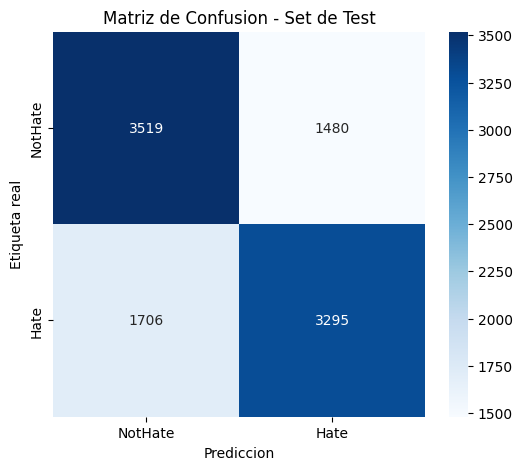

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NotHate", "Hate"],
    yticklabels=["NotHate", "Hate"],
)
plt.xlabel("Prediccion")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusion - Set de Test")
plt.show()


## 7. Reporte de clasificación completo

In [28]:
print(classification_report(y_true, y_pred, target_names=["NotHate", "Hate"]))


              precision    recall  f1-score   support

     NotHate       0.67      0.70      0.69      4999
        Hate       0.69      0.66      0.67      5001

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



## 8. Análisis de errores

Revisar ejemplos mal clasificados ayuda a entender las limitaciones reales del modelo (más allá de las métricas agregadas), y aporta contenido valioso para la sección de "Discusión" del README.

In [29]:
test_df["y_true"] = y_true
test_df["y_pred"] = y_pred

false_positives = test_df[(test_df["y_true"] == 0) & (test_df["y_pred"] == 1)]
false_negatives = test_df[(test_df["y_true"] == 1) & (test_df["y_pred"] == 0)]

print(f"Falsos positivos (NotHate clasificado como Hate): {len(false_positives)}")
print(f"Falsos negativos (Hate clasificado como NotHate): {len(false_negatives)}")

print("\n--- Ejemplos de falsos positivos ---")
print(false_positives[["text"]].head(5).to_string(index=False))

print("\n--- Ejemplos de falsos negativos ---")
print(false_negatives[["text"]].head(5).to_string(index=False))


Falsos positivos (NotHate clasificado como Hate): 1480
Falsos negativos (Hate clasificado como NotHate): 1706

--- Ejemplos de falsos positivos ---
                                                           text
        @tariqnasheed You better wash yo ass you dumbass faggot
                                        Fucken did as well cunt
@coleyworld #ResidentDumpschitt has been a tweeting twat today.
                                  I DIED ALOT MORE FUCKING CUNT
        Me at the next faggot that tries to step to my gay ass.

--- Ejemplos de falsos negativos ---
                                                                                                      text
                                                                                     i hate this nigga man
                                   @Ayanda_Bianca6 Twitter FBI can find out who that nigga is in 5 minutes
                                                                  Philly Philly come out and see a nigga 😎
  

## 9. Guardar resultados

Se guarda un resumen de métricas en formato JSON para referenciarlo fácilmente al redactar la sección "Resultados" del README, sin necesidad de volver a correr el notebook completo.

In [30]:
import json

results_summary = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "confusion_matrix": cm.tolist(),
    "n_test_samples": len(test_df),
    "n_false_positives": int(len(false_positives)),
    "n_false_negatives": int(len(false_negatives)),
}

with open(f"{PROCESSED_DIR}/resultados_test.json", "w", encoding="utf-8") as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)

print("Resultados guardados en resultados_test.json")
print(json.dumps(results_summary, indent=2))


Resultados guardados en resultados_test.json
{
  "accuracy": 0.6814,
  "precision": 0.6900523560209424,
  "recall": 0.6588682263547291,
  "f1": 0.6740998363338789,
  "confusion_matrix": [
    [
      3519,
      1480
    ],
    [
      1706,
      3295
    ]
  ],
  "n_test_samples": 10000,
  "n_false_positives": 1480,
  "n_false_negatives": 1706
}
